In [ ]:
import torch
x_data = [1.0, 2.0, 3.0]
y_data = [2.0, 4.0, 6.0]

In [12]:
w1 = torch.Tensor([1.0])
w1.requires_grad_(True)
w2 = torch.Tensor([2.0])
w2.requires_grad_(True)
b = torch.Tensor([0.0])
b.requires_grad_(True)


tensor([0.], requires_grad=True)

In [13]:
def forward(x):
    return w1 * (x ** 2) + w2 * x + b
def loss(x, y):
    y_pred = forward(x)
    return (y_pred - y) ** 2

In [14]:
import matplotlib.pyplot as plt
epochList= []
lossList = []

In [17]:
for epoch in range(100):
    for x,y in zip(x_data, y_data):
        l = loss(x, y)
        l.backward()
        # print(f"w1.grad={w1.grad.item():.4f}, w2.grad={w2.grad.item():.4f}, b.grad={b.grad.item():.4f}")    
        w1.data -= 0.01 * w1.grad.item()
        w2.data -= 0.01 * w2.grad.item()
        b.data -= 0.01 * b.grad.item()
        w1.grad.zero_()
        w2.grad.zero_()
        b.grad.zero_()
        print(f"w1={w1.item():.4f}, w2={w2.item():.4f}, b={b.item():.4f}")
    print('progress:', epoch, l.item())
    epochList.append(epoch)
    lossList.append(l.item())


w1=0.0284, w2=1.8749, b=0.1067
w1=0.0308, w2=1.8761, b=0.1073
w1=0.0285, w2=1.8754, b=0.1070
progress: 0 0.0001584583515068516
w1=0.0283, w2=1.8752, b=0.1068
w1=0.0307, w2=1.8763, b=0.1074
w1=0.0284, w2=1.8756, b=0.1071
progress: 1 0.00015453336527571082
w1=0.0282, w2=1.8754, b=0.1069
w1=0.0306, w2=1.8766, b=0.1075
w1=0.0284, w2=1.8758, b=0.1073
progress: 2 0.00015079809236340225
w1=0.0281, w2=1.8756, b=0.1070
w1=0.0305, w2=1.8768, b=0.1076
w1=0.0283, w2=1.8760, b=0.1074
progress: 3 0.00014728207315783948
w1=0.0281, w2=1.8758, b=0.1071
w1=0.0304, w2=1.8770, b=0.1077
w1=0.0282, w2=1.8762, b=0.1075
progress: 4 0.00014388759154826403
w1=0.0280, w2=1.8760, b=0.1072
w1=0.0303, w2=1.8772, b=0.1078
w1=0.0282, w2=1.8764, b=0.1076
progress: 5 0.00014067970914766192
w1=0.0279, w2=1.8762, b=0.1073
w1=0.0302, w2=1.8773, b=0.1079
w1=0.0281, w2=1.8766, b=0.1077
progress: 6 0.00013760864385403693
w1=0.0278, w2=1.8764, b=0.1074
w1=0.0301, w2=1.8775, b=0.1080
w1=0.0280, w2=1.8768, b=0.1078
progress: 7 

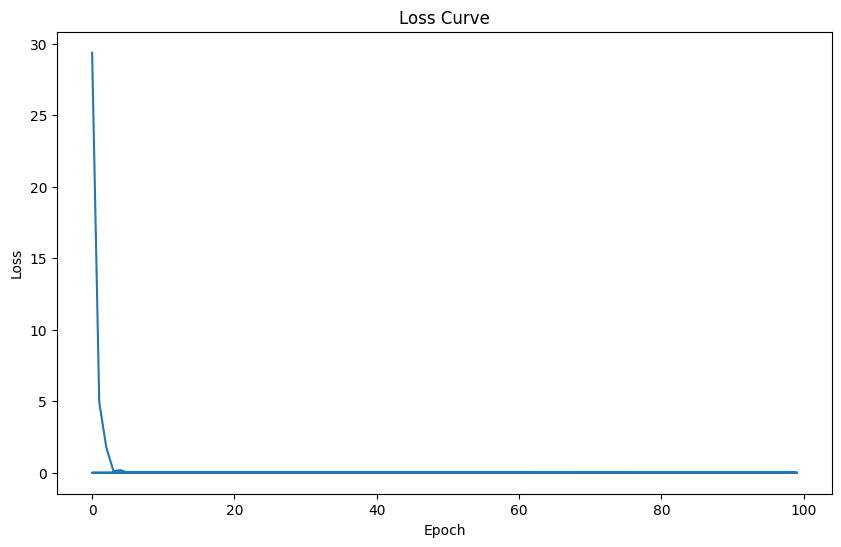

In [18]:
plt.figure(figsize=(10, 6), dpi=100)  # 10x6英寸，分辨率100
plt.plot(epochList, lossList)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()

In [19]:
# 1. 用epoch=5的收敛参数测试
w1_epoch5 = 0.0280
w2_epoch5 = 1.8760
b_epoch5 = 0.1072

# 2. 用epoch=99的最终参数测试
w1_epoch99 = 0.0252
w2_epoch99 = 1.8855
b_epoch99 = 0.1055

# 测试输入x=4，真实y=8
test_x = 4
true_y = 8

# 计算预测值（二次线性模型：y = w2*x + w1*x² + b）
pred_y_epoch5 = w2_epoch5 * test_x + w1_epoch5 * (test_x**2) + b_epoch5
pred_y_epoch99 = w2_epoch99 * test_x + w1_epoch99 * (test_x**2) + b_epoch99

# 打印结果
print(f"=== Epoch=5（收敛时）测试结果 ===")
print(f"预测值：{pred_y_epoch5:.4f}")
print(f"真实值：{true_y}")
print(f"绝对误差：{abs(true_y - pred_y_epoch5):.4f}")

print(f"\n=== Epoch=99（最终）测试结果 ===")
print(f"预测值：{pred_y_epoch99:.4f}")
print(f"真实值：{true_y}")
print(f"绝对误差：{abs(true_y - pred_y_epoch99):.4f}")

=== Epoch=5（收敛时）测试结果 ===
预测值：8.0592
真实值：8
绝对误差：0.0592

=== Epoch=99（最终）测试结果 ===
预测值：8.0507
真实值：8
绝对误差：0.0507
